In [1]:
from rosam.model import models
import numpy as np
import matplotlib.pyplot as plt
from rosam.model import sims
from rosam.utils import aux


In [7]:
import json

params = {}
params['delta'] = 0.01
params['alpha'] = 1
params['beta'] = 1
params['k'] = 0.4851
params['k_tet'] = 1
params['h1'] = 2.3435*0.0303
params['h2'] = 0.0303
params['tau_delay'] = 12
params['n']=3.6
params['n_tet'] = 2
params['c2'] = 0.0631
params['t_max'] = 960
params['sampling'] = 10

address = '/Users/hossein/Documents/Projects/RoSAM/'
aux.save_params(params,address)

In [13]:


t_max = 960 #16 h
num_cells = 600
stims = {}

for i in range(num_cells):
    np.random.seed(10*i+10)
    if i<500:
        stims[f'cell {i+1}'] = aux.random_stim_maker(int((t_max)/5)).tolist()
    if i>=500 and i<550:
        stims[f'cell {i+1}'] = aux.repetitive_stim_maker(i+1-500,int((t_max)/5),False).tolist()
    if i>=550 and i<600:
        stims[f'cell {i+1}'] = aux.repetitive_stim_maker(i+1-550,int((t_max)/5),True).tolist()
     #aux.repetitive_stim_maker(i+1,int((t_max)/5),True)
    #stims[f'cell {i+1}'] = np.concatenate([[0]* 36 ,  aux.repetitive_stim_maker(i+1,int((t_max-36*5)/5),True)])
    #stims[f'cell {i+1}'] = np.concatenate([[0]* 36 ,  aux.random_stim_maker(int((t_max-36*5)/5))])
    
num_realizations = 3

aux.save_stims(stims,address)


In [ ]:
experiment_config = {'t_max':960,'num_cells':600,'num_realizations':3,'root_folder':""}

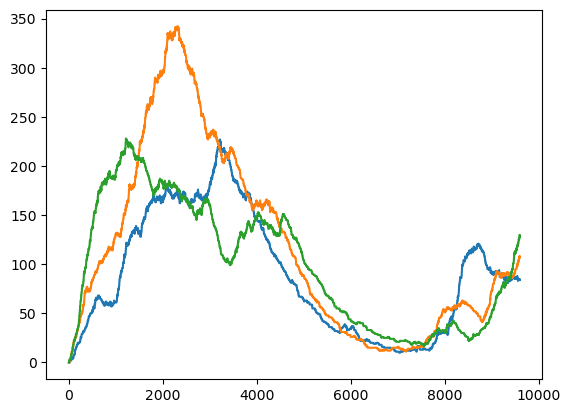

In [ ]:
xpt = sims.experiment(params,'ccasr')
xpt.init_exp(num_cells)
xpt.run_training_sim(stims)
xpt.save_cells(address)


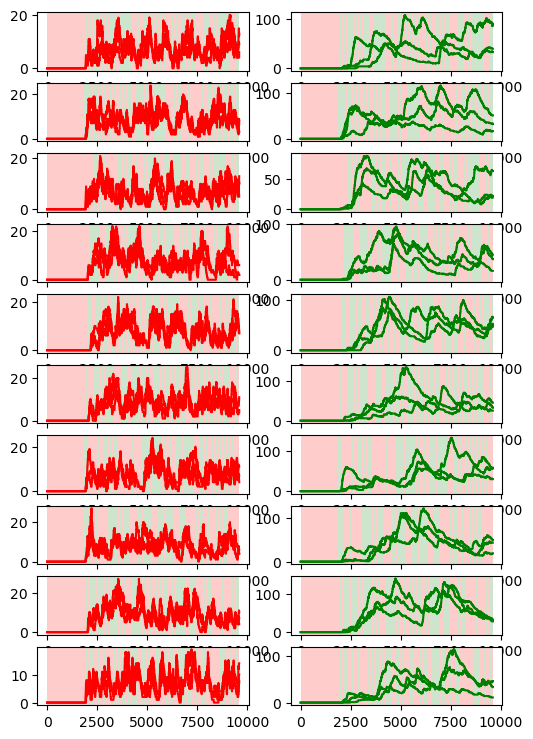

In [10]:
fig, ax = plt.subplots(num_cells,2,figsize = (6,9))

for i in range(num_cells):
    aux.background_plotter(ax[i][0],stims[f'cell {i+1}'])
    aux.background_plotter(ax[i][1],stims[f'cell {i+1}'])
    for j in range(num_realizations):        
        ax[i][1].plot(xpt.Cells[f'{i+1}'].expressions['F'][0][j,:],color = 'green')
        ax[i][0].plot(xpt.Cells[f'{i+1}'].expressions['H'][0][j,:], color = 'red')